In [16]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from random import randint
import torchvision.models as models
import torch.nn as nn
import tqdm
import umap
from sklearn.manifold import TSNE
import seaborn as sns
import os
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
import random

In [7]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
# 1. Paths & Transforms
data_dir = r"C:\Users\rafin\Desktop\465_Project\CSE465_FeatureUnderstanding\data\caltech-101"

transform = transforms.Compose([
    transforms.Resize((224, 224)),    # ResNet input
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 2. Load Caltech-101 via ImageFolder
#    (Caltech-101 has class folders; ImageFolder will infer labels)
full_dataset = ImageFolder(root=data_dir, transform=transform)

# 3. Train/Test Split (e.g., 80/20)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

print(f"Total images: {len(full_dataset)}, Train: {len(train_dataset)}, Test: {len(test_dataset)}")
print("Classes:", full_dataset.classes)

Total images: 9144, Train: 7315, Test: 1829
Classes: ['BACKGROUND_Google', 'Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass', 'beaver', 'binocular', 'bonsai', 'brain', 'brontosaurus', 'buddha', 'butterfly', 'camera', 'cannon', 'car_side', 'ceiling_fan', 'cellphone', 'chair', 'chandelier', 'cougar_body', 'cougar_face', 'crab', 'crayfish', 'crocodile', 'crocodile_head', 'cup', 'dalmatian', 'dollar_bill', 'dolphin', 'dragonfly', 'electric_guitar', 'elephant', 'emu', 'euphonium', 'ewer', 'ferry', 'flamingo', 'flamingo_head', 'garfield', 'gerenuk', 'gramophone', 'grand_piano', 'hawksbill', 'headphone', 'hedgehog', 'helicopter', 'ibis', 'inline_skate', 'joshua_tree', 'kangaroo', 'ketch', 'lamp', 'laptop', 'llama', 'lobster', 'lotus', 'mandolin', 'mayfly', 'menorah', 'metronome', 'minaret', 'nautilus', 'octopus', 'okapi', 'pagoda', 'panda', 'pigeon', 'pizza', 'platypus', 'pyramid', 'revolver', 'rhino', 'rooster', 'saxophone', 'schoone

Label: Faces_easy


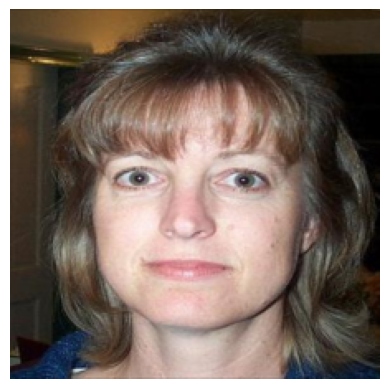

In [5]:
# 4. DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=12)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=12)

# 5. (Optionally) Sanity‐check one batch
def imshow(img):
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

images, labels = next(iter(train_loader))
imshow(images[0])
print("Label:", full_dataset.classes[labels[0]])

In [8]:
# Load pretrained ResNet-101, drop final fc
resnet101 = models.resnet101(pretrained=True)
model = nn.Sequential(*list(resnet101.children())[:-1])

# Set to evaluation mode
model.eval()

# Send to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [12]:
# Extract embeddings on test_dataset
all_embeddings, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in tqdm.tqdm(test_loader):
        imgs = imgs.to(device)
        feats = model(imgs).squeeze()          # [B, 2048, 1, 1] → [B, 2048]
        if feats.dim()==1: feats = feats.unsqueeze(0)
        all_embeddings.append(feats.cpu())
        all_labels.append(lbls)
all_embeddings = torch.cat(all_embeddings).numpy()
all_labels     = torch.cat(all_labels).numpy()

# Save
os.makedirs("embeddings_101", exist_ok=True)
np.save("embeddings_101/resnet101_caltech101_embeddings.npy", all_embeddings)
np.save("embeddings_101/resnet101_caltech101_labels.npy",     all_labels)

100%|██████████| 29/29 [00:26<00:00,  1.11it/s]


In [13]:
embeddings = np.load("embeddings_101/resnet101_caltech101_embeddings.npy")
labels = np.load("embeddings_101/resnet101_caltech101_labels.npy")

print("Embeddings shape:", embeddings.shape)
print("Labels shape:", labels.shape)

Embeddings shape: (1829, 2048)
Labels shape: (1829,)


C:\Users\rafin\AppData\Local\Temp\ipykernel_22660\1370464522.py:8: UserWarning: 
The palette list has fewer values (101) than needed (102) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(x=embedding_2d[:, 0], y=embedding_2d[:, 1], hue=labels, palette=palette, s=15, linewidth=0)
C:\Users\rafin\AppData\Local\Temp\ipykernel_22660\1370464522.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


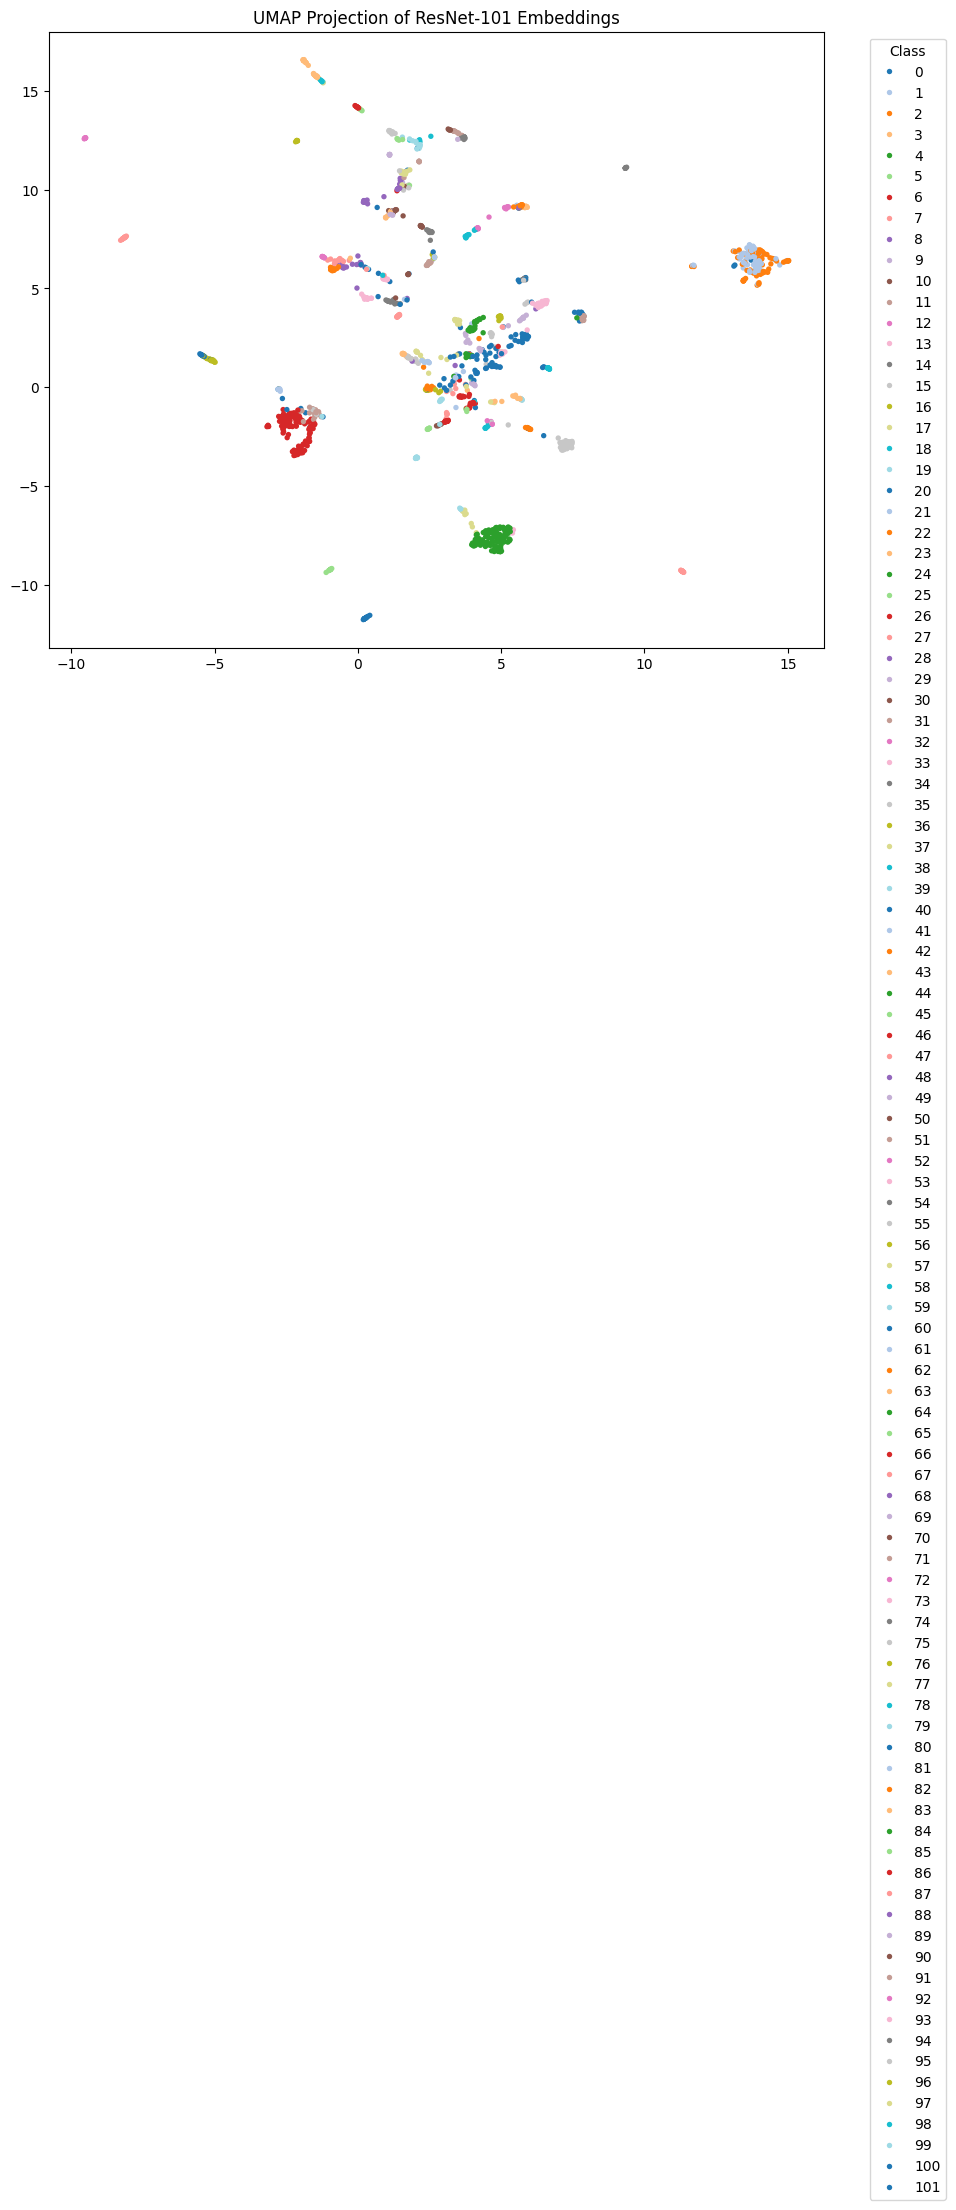

In [ ]:
reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, metric='cosine')
embedding_2d = reducer.fit_transform(embeddings)  # Shape: [10000, 2]


palette = sns.color_palette("tab20", n_colors=101)
#sns.scatterplot(..., palette=palette, ...)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_2d[:, 0], y=embedding_2d[:, 1], hue=labels, palette=palette, s=15, linewidth=0)
plt.title("UMAP Projection of ResNet-101 Embeddings")
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='best')
plt.tight_layout()
plt.show()

C:\Users\rafin\AppData\Local\Temp\ipykernel_22660\534492844.py:5: UserWarning: 
The palette list has fewer values (101) than needed (102) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(x=tsne_2d[:, 0], y=tsne_2d[:, 1], hue=labels, palette=palette, s=15, linewidth=0)
C:\Users\rafin\AppData\Local\Temp\ipykernel_22660\534492844.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


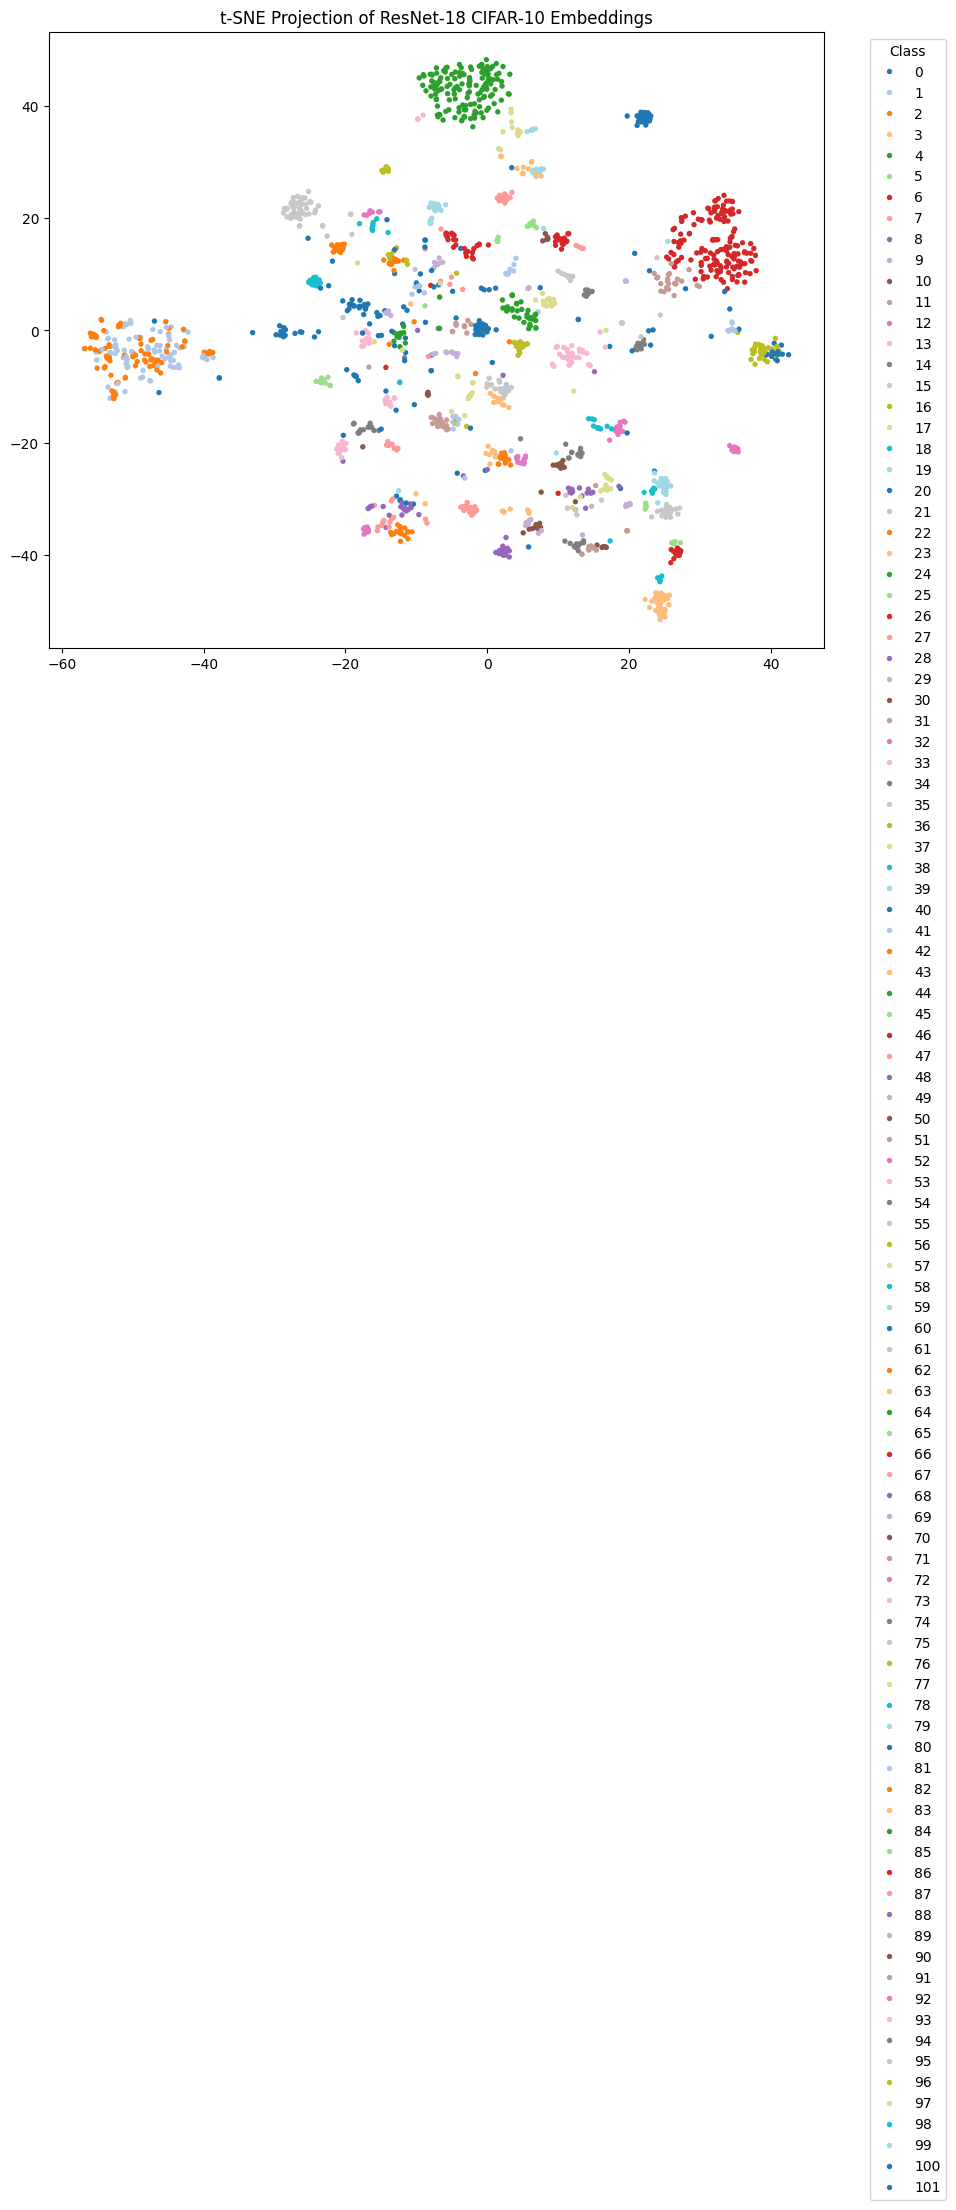

In [21]:
tsne = TSNE(n_components=2, perplexity=30, metric='cosine', n_iter=1000)
tsne_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=tsne_2d[:, 0], y=tsne_2d[:, 1], hue=labels, palette=palette, s=15, linewidth=0)
plt.title("t-SNE Projection of ResNet-18 CIFAR-10 Embeddings")
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [24]:
# Map each class label to list of indices
label_to_indices = defaultdict(list)
for idx, label in enumerate(labels):
    label_to_indices[label].append(idx)

# Randomly pick one index per class (for top 10 classes)
class_to_idx = {}
top_k = 10
selected_labels = list(label_to_indices.keys())[:top_k]  # You can shuffle this if needed

for label in selected_labels:
    class_to_idx[label] = random.choice(label_to_indices[label])


top_k = 10
results = {}

for class_label, query_idx in class_to_idx.items():
    query_embedding = embeddings[query_idx].reshape(1, -1)

    # Compute cosine similarity to all embeddings
    similarities = cosine_similarity(query_embedding, embeddings)[0]  # shape: [10000]

    # Get top K most similar indices (excluding the query itself)
    similar_indices = similarities.argsort()[::-1][1:top_k+1]

    results[class_label] = {
        "query_idx": query_idx,
        "neighbors": similar_indices
    }
    
    
def unnormalize(img_tensor):
    """
    Undo normalization to convert image tensor to [0,1] range for imshow
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_tensor = img_tensor.cpu() * std + mean
    img_tensor = torch.clamp(img_tensor, 0, 1)
    return img_tensor


def show_neighbors(dataset, query_idx, neighbor_indices, class_name):
    plt.figure(figsize=(12, 2))

    # Query image
    plt.subplot(1, top_k + 1, 1)
    query_img = unnormalize(dataset[query_idx][0])
    plt.imshow(query_img.permute(1, 2, 0).numpy())
    plt.title(f"Query\nClass: {class_name}")
    plt.axis('off')

    # Neighbors
    for i, idx in enumerate(neighbor_indices):
        plt.subplot(1, top_k + 1, i + 2)
        nn_img = unnormalize(dataset[idx][0])
        plt.imshow(nn_img.permute(1, 2, 0).numpy())

        # Get the actual label name from dataset.labels or dataset.targets
        nn_label_idx = dataset[idx][1]  # This is the label index
        nn_label_name = dataset.dataset.classes[nn_label_idx]


        plt.title(f"NN {i+1}\n{nn_label_name}", fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

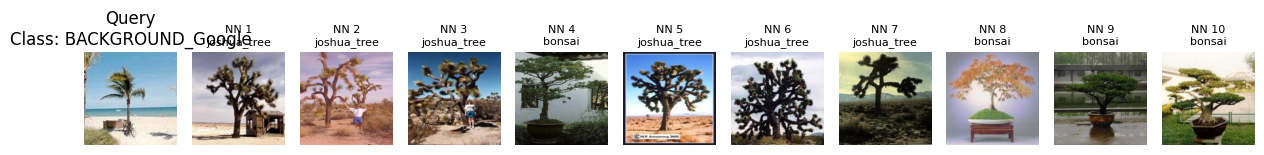

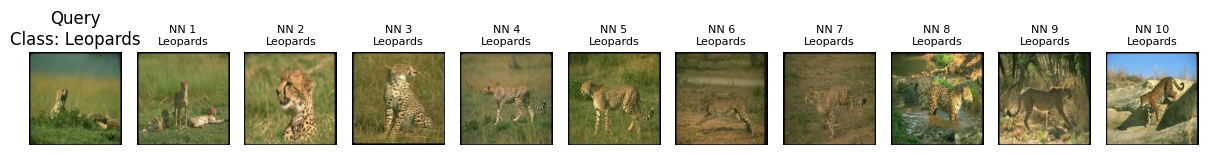

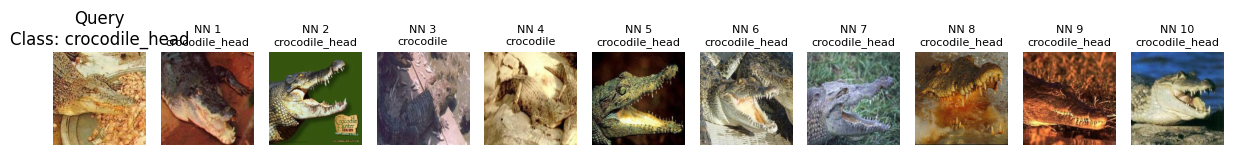

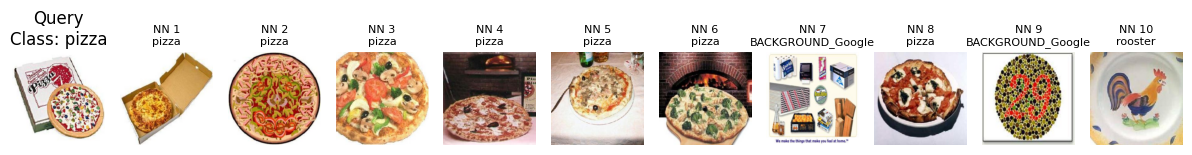

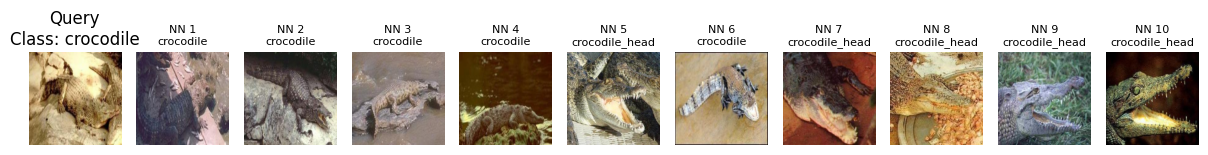

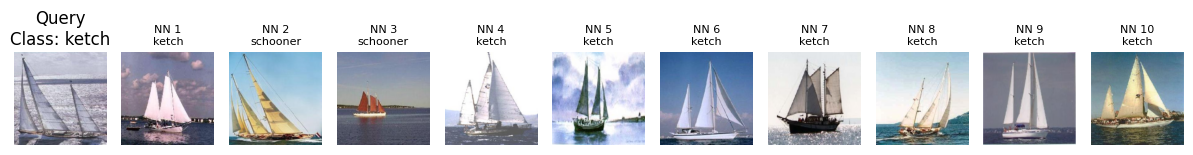

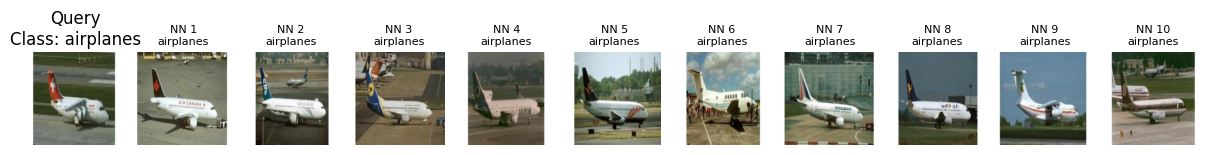

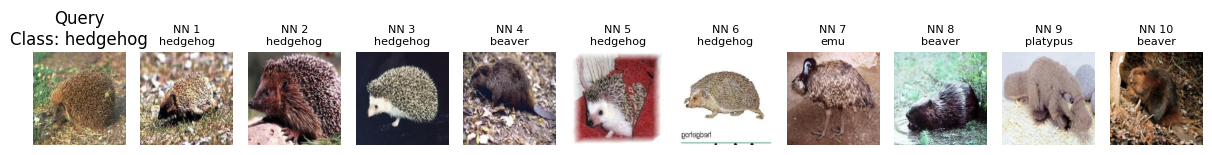

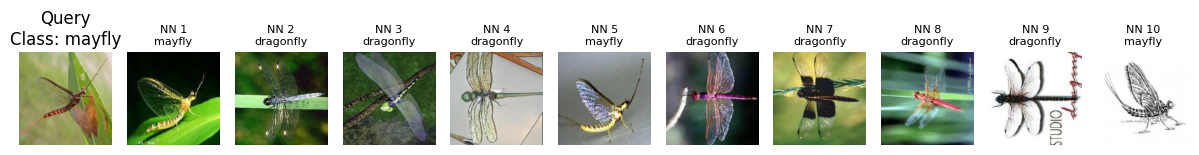

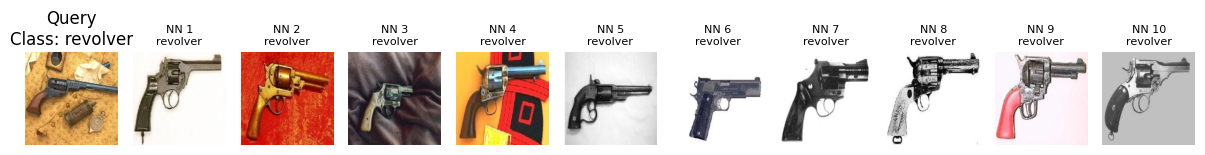

In [25]:
for class_label, data in results.items():
    show_neighbors(
        dataset=test_dataset,
        query_idx=data["query_idx"],
        neighbor_indices=data["neighbors"],
        class_name=test_dataset.dataset.classes[class_label]   # ← note the extra `.dataset`
    )

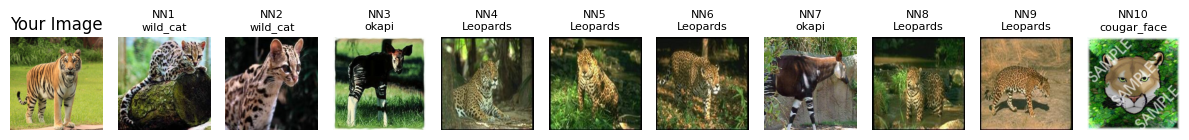

In [27]:

from PIL import Image

# Parameters
your_image_path = "tiger.jpg"  
top_k = 10

# 1. Load and preprocess your image
img = Image.open(your_image_path).convert("RGB")
img_t = transform(img).unsqueeze(0).to(device)  # reuse `transform` and `device` from above

# 2. Extract its embedding
model.eval()
with torch.no_grad():
    feat = model(img_t)         # [1, 512, 1, 1]
    feat = feat.squeeze().cpu().numpy().reshape(1, -1)

# 3. Compute cosine similarities to all saved embeddings
all_emb = embeddings          # loaded earlier: np.load("embeddings/...npy")
sims = cosine_similarity(feat, all_emb)[0]

# 4. Get top_k neighbor indices (skip the image itself if accidentally included)
neighbor_idxs = sims.argsort()[::-1][:top_k]

# 5. Display query + neighbors
plt.figure(figsize=(12, 2))

# Query
plt.subplot(1, top_k+1, 1)
plt.imshow(img.resize((224,224)))
plt.title("Your Image")
plt.axis("off")

# Neighbors
for i, idx in enumerate(neighbor_idxs):
    ds_img, ds_lbl = test_dataset[idx]
    nn_img = unnormalize(ds_img)  # reuse unnormalize function
    plt.subplot(1, top_k+1, i+2)
    plt.imshow(nn_img.permute(1,2,0).numpy())
    plt.title(f"NN{i+1}\n{test_dataset.dataset.classes[ds_lbl]}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()